In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/javeriaismail99/cg-general/CC GENERAL.csv


In [2]:
#DATA LOADING 
import pandas as pd
DATA_PATH = "/kaggle/input/datasets/javeriaismail99/cg-general/CC GENERAL.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape); print(df.head())

(8950, 18)
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.00

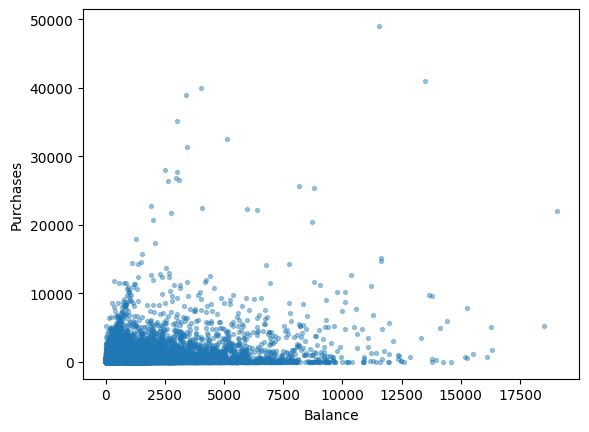

In [3]:
#VISUALIZATION
import matplotlib.pyplot as plt
plt.scatter(df["BALANCE"], df["PURCHASES"], s=8, alpha=0.4)
plt.xlabel("Balance"); plt.ylabel("Purchases"); plt.show()

In [4]:
#PREPROCESSING
from sklearn.preprocessing import StandardScaler
feature_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
X_scaled = StandardScaler().fit_transform(df[feature_cols].values)

In [5]:
#TRAINING
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [6]:
#TEST
df["Cluster"] = kmeans.predict(X_scaled)
print(df["Cluster"].value_counts())

Cluster
1    5991
0    2092
2     788
3      79
Name: count, dtype: int64


In [7]:
#VALIDATION
from sklearn.metrics import silhouette_score
print(silhouette_score(X_scaled, df["Cluster"]))
print(df.groupby("Cluster")[feature_cols].mean())

0.4038375623453519
             BALANCE     PURCHASES  CASH_ADVANCE  CREDIT_LIMIT      PAYMENTS
Cluster                                                                     
0        2038.788401   1965.051477    639.905956   7983.977925   2503.883960
1         788.150522    491.801187    483.805473   2526.763774    868.739008
2        5918.962965    853.247297   5607.605148   9353.939778   4609.398988
3        4442.427570  15810.832785   1328.376614  12817.721519  18185.954830
